In [4]:
pip install seaborn 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv('Social_Network_Ads.csv')

In [8]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [7]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
#Train test split is necessary before Feature scaling 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop("Purchased", axis=1),df['Purchased'],test_size=0.4,random_state=0)

In [9]:
x_train,x_test

(     Age  EstimatedSalary
 281   35            61000
 133   21            68000
 33    28            44000
 378   41            87000
 162   37            33000
 ..   ...              ...
 323   48            30000
 192   29            43000
 117   36            52000
 47    27            54000
 172   26           118000
 
 [240 rows x 2 columns],
      Age  EstimatedSalary
 132   30            87000
 309   38            50000
 341   35            75000
 196   30            79000
 246   35            50000
 ..   ...              ...
 136   20            82000
 275   57            74000
 126   42            65000
 198   26            80000
 299   46           117000
 
 [160 rows x 2 columns])

In [10]:
from sklearn.preprocessing import StandardScaler
st=StandardScaler()
st.fit(x_train)
x_train_scaled=st.transform(x_train)
x_test_scaled=st.transform(x_test)
st.mean_

array([3.77208333e+01, 6.79625000e+04])

In [11]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled, columns=x_test.columns)






In [12]:
x_test_scaled

,Age,EstimatedSalary
0,-0.757632,0.557289
1,0.027394,-0.525820
2,-0.266991,0.206010
3,-0.757632,0.323103
4,-0.266991,-0.525820
...,...,...
155,-1.738915,0.410923
156,1.891831,0.176737
157,0.419907,-0.086722
158,-1.150145,0.352376


<Axes: xlabel='Age', ylabel='EstimatedSalary'>

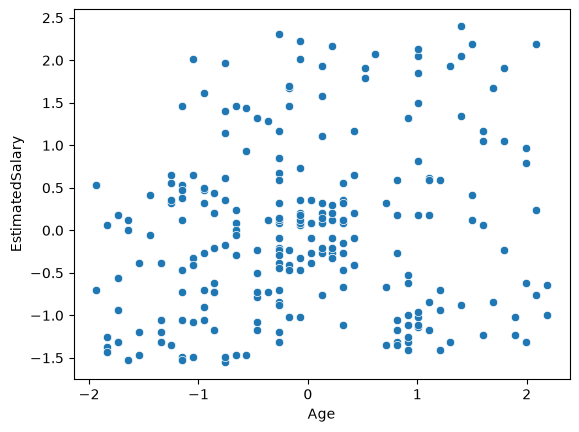

In [13]:
sns.scatterplot(x=x_train_scaled['Age'],y=x_train_scaled['EstimatedSalary'])

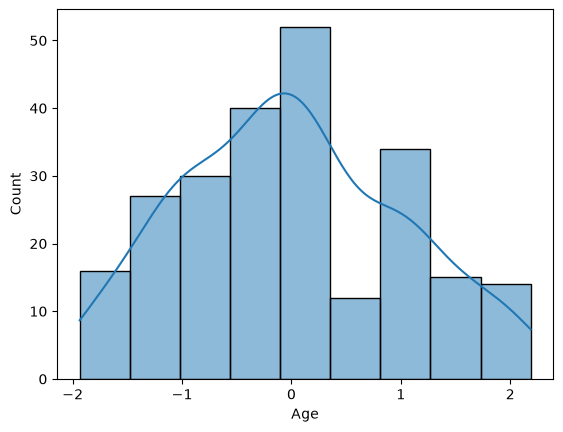

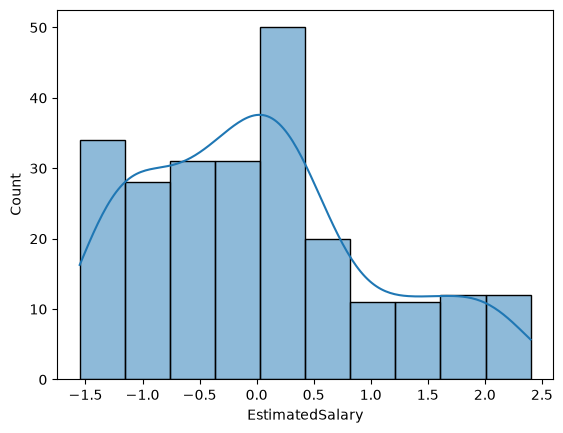

In [14]:
sns.histplot(x_train_scaled['Age'], kde=True)
plt.show()

sns.histplot(x_train_scaled['EstimatedSalary'], kde=True)
plt.show()

In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
lr=LogisticRegression()


In [18]:
lr.fit(x_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [19]:
y_prd=lr.predict(x_test_scaled)

In [20]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_prd)*100)

85.625


In [31]:
from sklearn.preprocessing import MinMaxScaler
minmax=MinMaxScaler()
minmax.fit(x_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](2,)","[ 60.,150000.]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](2,)","[ 18.,15000.]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](2,)","[ 42.,135000.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Age','EstimatedSalary']"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](2,)","[-0.43,-0.11]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,240


In [34]:
X_trained = minmax.transform(x_train)
X_tested = minmax.transform(x_test)

X_trained = pd.DataFrame(X_trained, columns=x_train.columns)
X_tested = pd.DataFrame(X_tested, columns=x_test.columns)

In [35]:
X_trained

,Age,EstimatedSalary
0,0.404762,0.340741
1,0.071429,0.392593
2,0.238095,0.214815
3,0.547619,0.533333
4,0.452381,0.133333
...,...,...
235,0.714286,0.111111
236,0.261905,0.207407
237,0.428571,0.274074
238,0.214286,0.288889


In [36]:
np.round(X_trained.describe(),1)

,Age,EstimatedSalary
count,240.0,240.0
mean,0.5,0.4
std,0.2,0.3
min,0.0,0.0
25%,0.3,0.2
50%,0.5,0.4
75%,0.7,0.5
max,1.0,1.0


<Axes: xlabel='Age', ylabel='EstimatedSalary'>

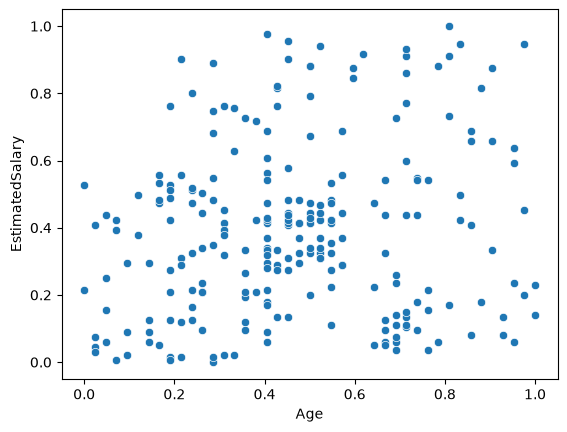

In [37]:
sns.scatterplot(x=X_trained['Age'],y=X_trained['EstimatedSalary']) 
#a same graph done with the standardisation

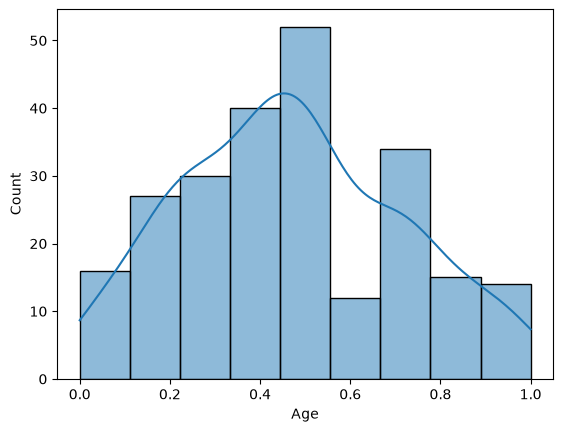

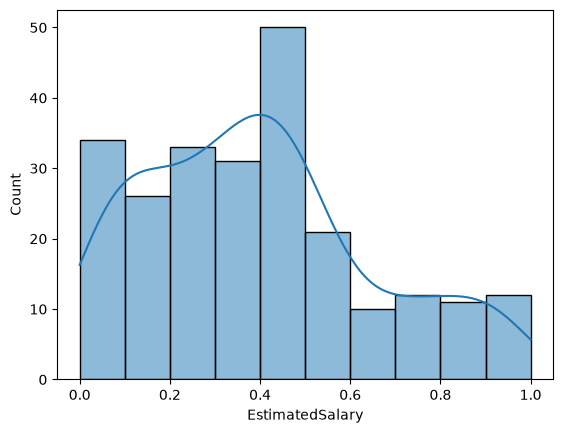

In [38]:
sns.histplot(X_trained['Age'], kde=True)
plt.show()

sns.histplot(X_trained['EstimatedSalary'], kde=True)
plt.show()

In [47]:
#ROBUST SCALING
from sklearn.preprocessing import RobustScaler
sc=RobustScaler()
sc.fit(x_train)

RobustScaler()

In [49]:
x_sctrain=sc.transform(x_train)
x_sctest=sc.transform(x_test)
x_sctrain=pd.DataFrame(x_sctrain,columns=x_train.columns)
x_sctest=pd.DataFrame(x_sctest, columns=x_test.columns)





In [51]:
x_sctrain

,Age,EstimatedSalary
0,-0.1250,-0.101124
1,-1.0000,0.056180
2,-0.5625,-0.483146
3,0.2500,0.483146
4,0.0000,-0.730337
...,...,...
235,0.6875,-0.797753
236,-0.5000,-0.505618
237,-0.0625,-0.303371
238,-0.6250,-0.258427


<Axes: xlabel='Age', ylabel='EstimatedSalary'>

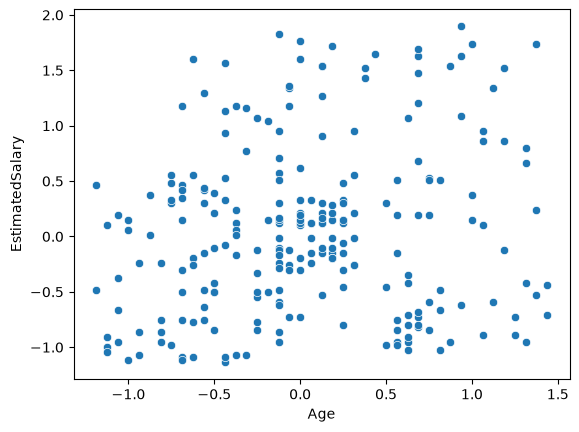

In [52]:
sns.scatterplot(x=x_sctrain['Age'],y=x_sctrain['EstimatedSalary'])